# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
#Read the data file
df = pd.read_csv("cancer.csv")
df.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
df.duplicated().sum()

8

Remove duplicate entries from same patient.
Don't remove values from different patients

In [4]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [5]:
#The results suggest there are 8 duplicate rows in the breast cancer dataset. 
#Although such duplicate rows may correspond to samples for different individuals, duplicates may be
#the samples taken from the same individual and illustrate below how to remove the duplicated rows.

In [6]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done
df=df.drop(['ID'],axis=1)
df.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [7]:
df.shape

(691, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null object
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: int64(9), object(1)
memory usage: 59.4+ KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ClumpThickness,691.0,4.426918,2.815861,1.0,2.0,4.0,6.0,10.0
Cell Size,691.0,3.130246,3.041328,1.0,1.0,1.0,5.0,10.0
Cell Shape,691.0,3.201158,2.959886,1.0,1.0,1.0,5.0,10.0
Marginal Adhesion,691.0,2.824891,2.866552,1.0,1.0,1.0,4.0,10.0
Single Epithelial Cell Size,691.0,3.211288,2.199852,1.0,2.0,2.0,4.0,10.0
Normal Nucleoli,691.0,3.435601,2.442345,1.0,2.0,3.0,5.0,10.0
Bland Chromatin,691.0,2.882779,3.066298,1.0,1.0,1.0,4.0,10.0
Mitoses,691.0,1.593343,1.723129,1.0,1.0,1.0,1.0,10.0
Class,691.0,2.688857,0.951051,2.0,2.0,2.0,4.0,4.0


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [10]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [11]:
df.isnull().values.any()

False

In [12]:
df.isna().values.any()

False

In [13]:
df = df.replace('?',np.NaN)

print('Number of instances = %d' % (df.shape[0]))
print('Number of attributes = %d' % (df.shape[1]))

print('Number of not applicable  values:')
for col in df.columns:
    print('\t%s: %d' % (col,df[col].isna().sum()))
    
print('Number of null values:')
for col in df.columns:
    print('\t%s: %d' % (col,df[col].isnull().sum()))

Number of instances = 691
Number of attributes = 10
Number of not applicable  values:
	ClumpThickness: 0
	Cell Size: 0
	Cell Shape: 0
	Marginal Adhesion: 0
	Single Epithelial Cell Size: 0
	Bare Nuclei: 16
	Normal Nucleoli: 0
	Bland Chromatin: 0
	Mitoses: 0
	Class: 0
Number of null values:
	ClumpThickness: 0
	Cell Size: 0
	Cell Shape: 0
	Marginal Adhesion: 0
	Single Epithelial Cell Size: 0
	Bare Nuclei: 16
	Normal Nucleoli: 0
	Bland Chromatin: 0
	Mitoses: 0
	Class: 0


In [14]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
df[df['Bare Nuclei'] == False].count()

ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [15]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [16]:
df['Bare Nuclei'] = df['Bare Nuclei'].apply(pd.to_numeric, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    675 non-null float64
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: float64(1), int64(9)
memory usage: 59.4 KB


Replace missing values with median

In [17]:
df['Bare Nuclei'].fillna((df['Bare Nuclei'].median()), inplace=True)
df.isnull().sum()

ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [18]:
df.shape

(691, 10)

Remove duplicate entries from same patient, which is already done.
Don't remove values from different patients.
IDs are removed as well

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [19]:
# Check for correlation of variable

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

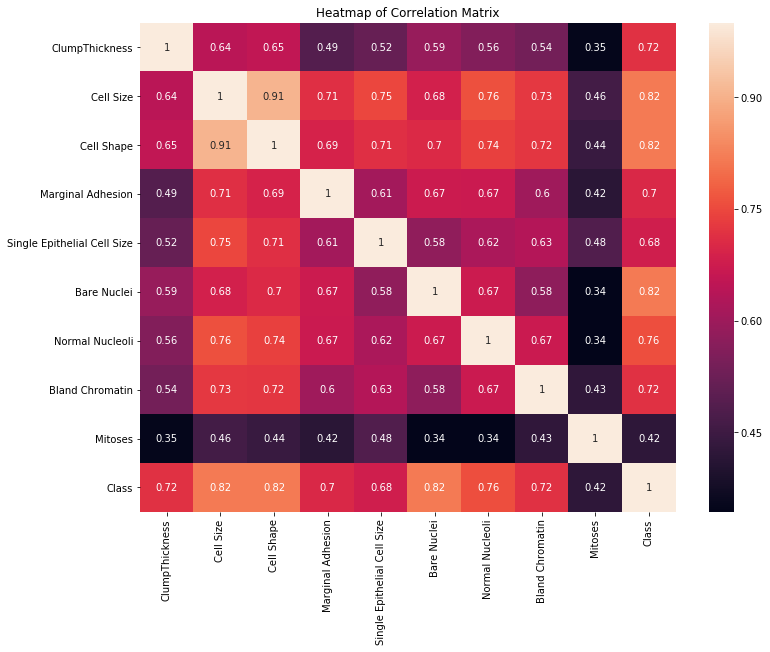

In [20]:
#Let's see how these data are correlated
col_names =df.columns
corr_matrix = df[col_names].corr().abs()
plt.figure(figsize = (12,9))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(corr_matrix,annot=True)#, xticklabels=corr_matrix.columns.values, yticklabels=corr_matrix.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

In [21]:
corr_matrix

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.643340,0.653752,0.487949,0.517448,0.590841,0.561076,0.535712,0.350354,0.716938
Cell Size,0.643340,1.000000,0.905420,0.713117,0.747111,0.684791,0.759525,0.727239,0.460064,0.817720
Cell Shape,0.653752,0.905420,1.000000,0.690989,0.714393,0.704382,0.738455,0.724693,0.440592,0.817693
Marginal Adhesion,0.487949,0.713117,0.690989,1.000000,0.608477,0.672719,0.669813,0.602453,0.417167,0.701371
Single Epithelial Cell Size,0.517448,0.747111,0.714393,0.608477,1.000000,0.580709,0.620518,0.634058,0.482644,0.681233
Bare Nuclei,0.590841,0.684791,0.704382,0.672719,0.580709,1.000000,0.672687,0.578417,0.343020,0.816787
Normal Nucleoli,0.561076,0.759525,0.738455,0.669813,0.620518,0.672687,1.000000,0.669059,0.343821,0.756618
Bland Chromatin,0.535712,0.727239,0.724693,0.602453,0.634058,0.578417,0.669059,1.000000,0.427644,0.715540
Mitoses,0.350354,0.460064,0.440592,0.417167,0.482644,0.343020,0.343821,0.427644,1.000000,0.424111
Class,0.716938,0.817720,0.817693,0.701371,0.681233,0.816787,0.756618,0.715540,0.424111,1.000000


1.Target variable shows high correlation with most of these variables.

2.Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli and bland chromatin.

3.Cell shape shows high significance with cell size,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli and bland chromatin.

4.Normal nucleoli shows high significance with bland chromatin and bare nuclei.

In [22]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


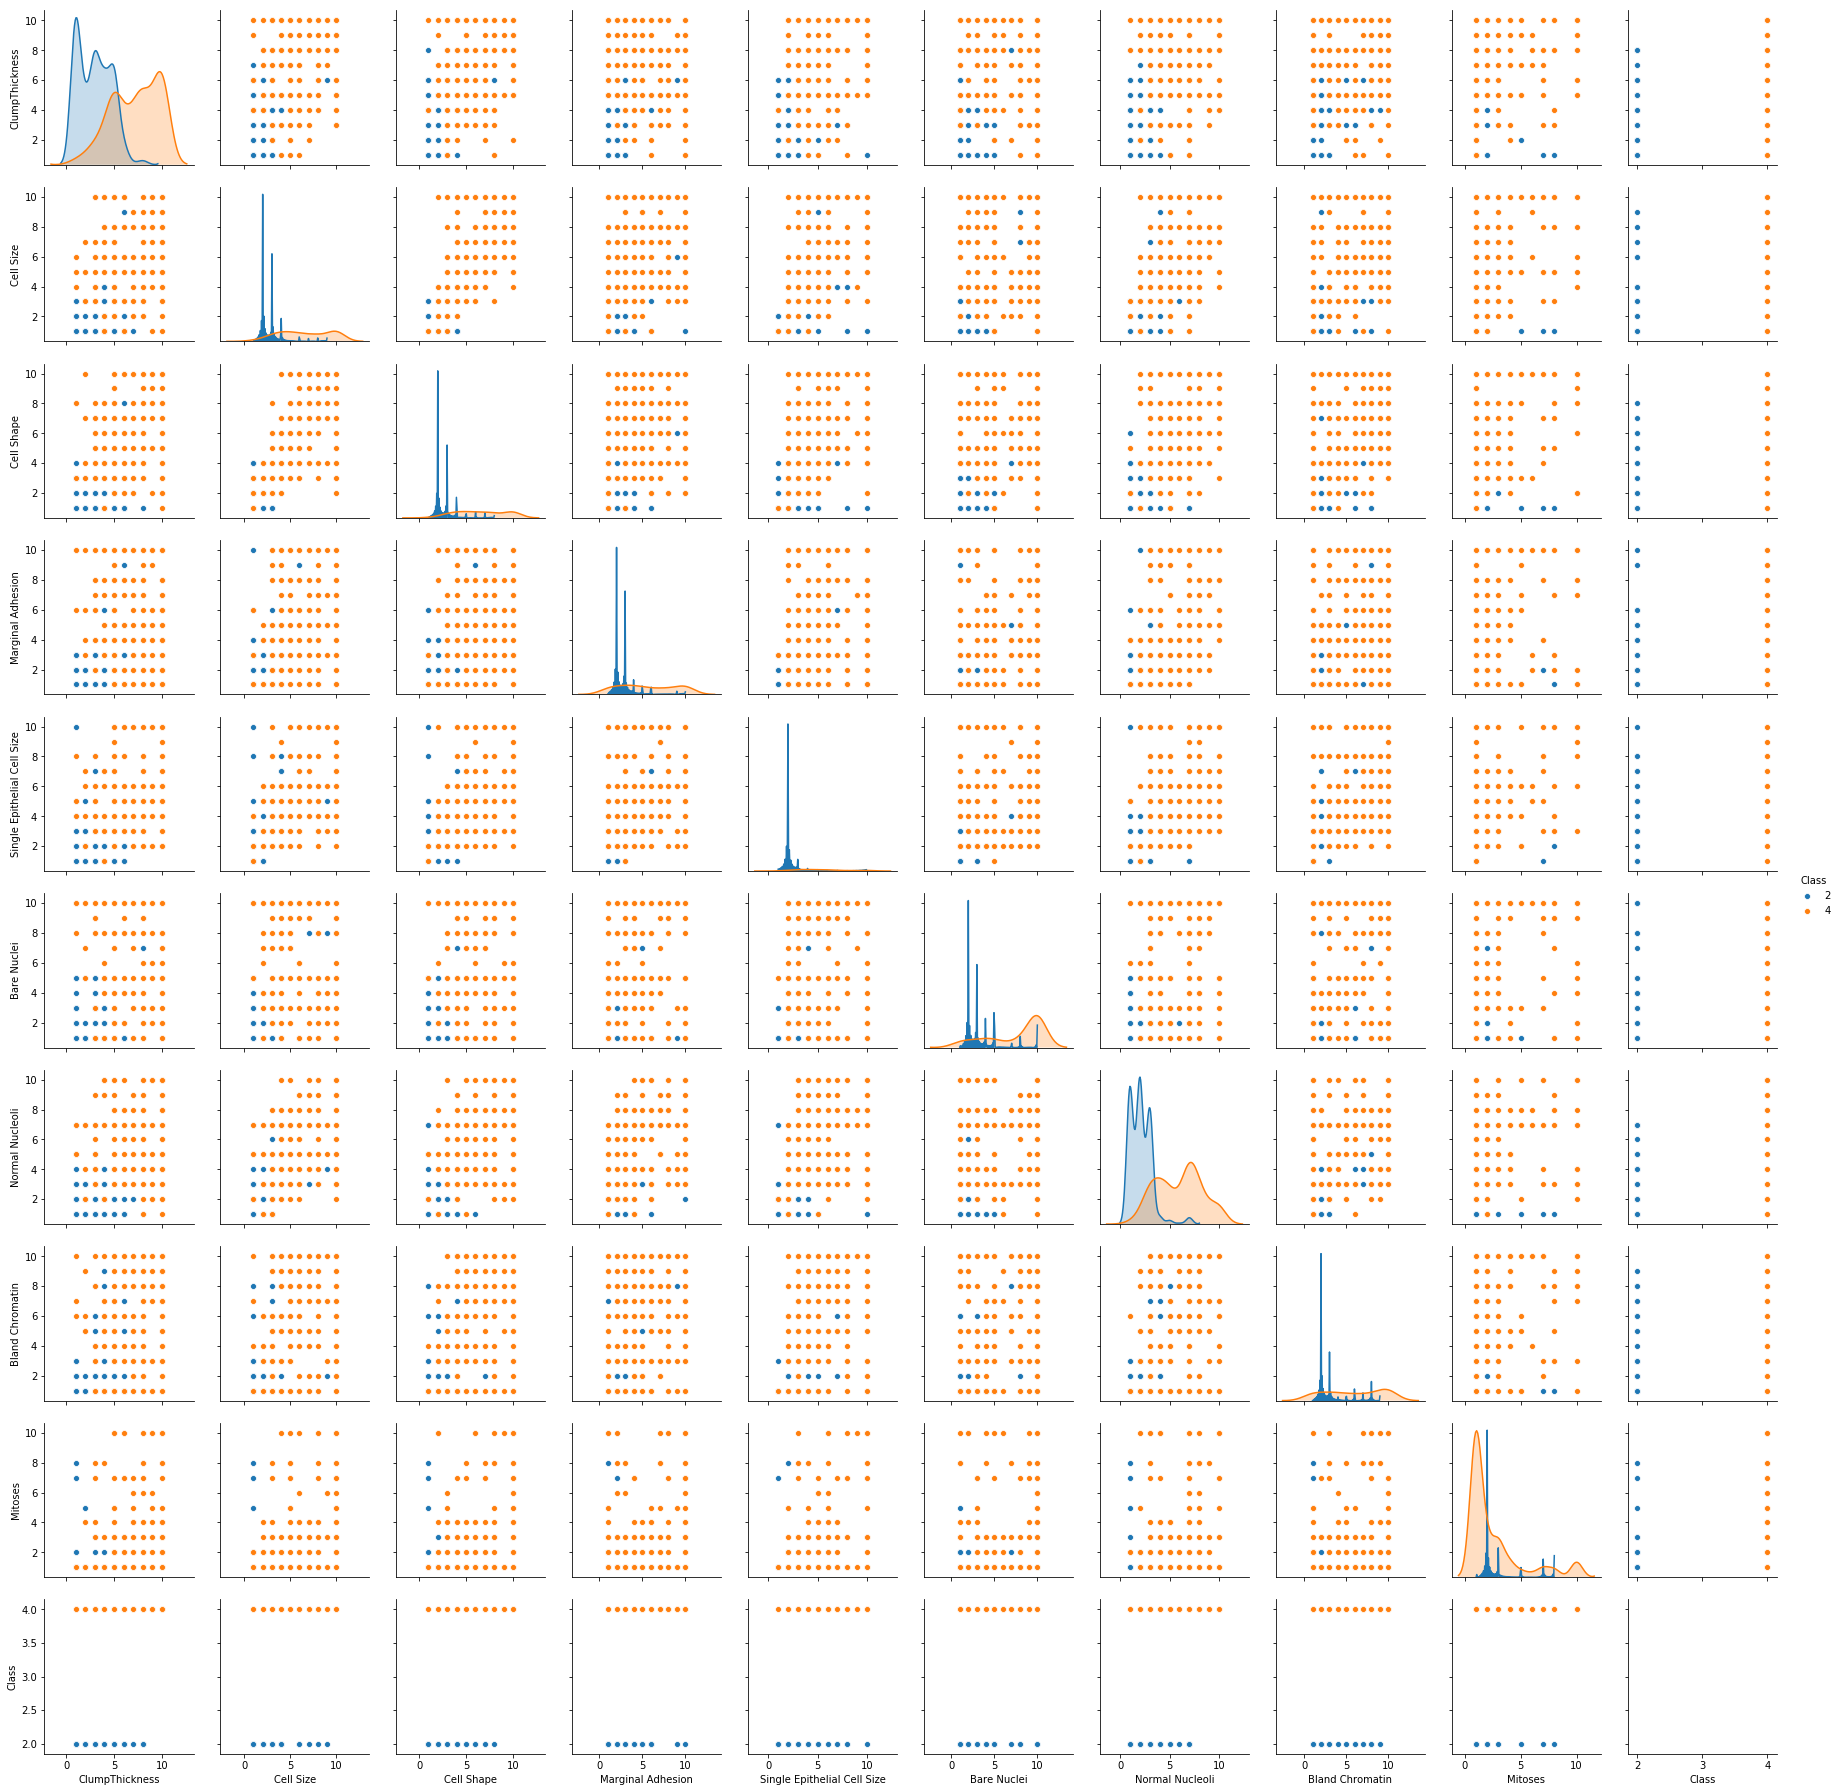

In [23]:
#Let us check for pair plots
sns.pairplot(df, diag_kind = "kde", hue = "Class")

Observing from pair plot as well, outliers are not see but most columns have mutliple peaks and disttribution is wide

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [24]:
# We could see most of the outliers are now removed.

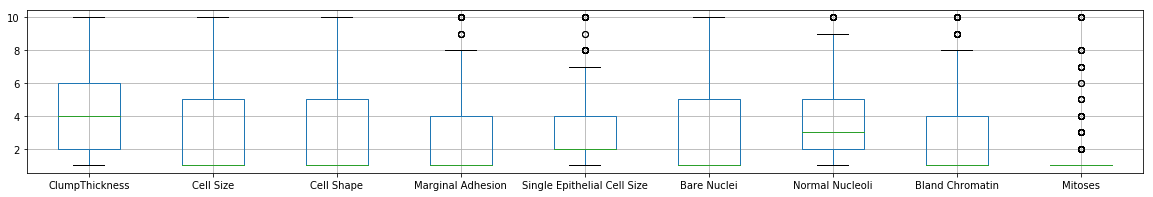

In [25]:
X = df.drop("Class", axis=1)
X.boxplot(figsize=[20,3])
y = df["Class"]

In [26]:
df.columns

Index(['ClumpThickness', 'Cell Size', 'Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli',
       'Bland Chromatin', 'Mitoses', 'Class'],
      dtype='object')

Skewness :  1.7190414829921783
Kurtosis :  2.215127491507251


C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


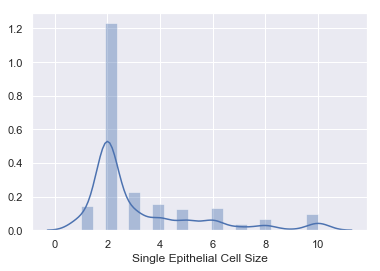

In [27]:
print('Skewness : ',df["Single Epithelial Cell Size"].skew())
print('Kurtosis : ',df["Single Epithelial Cell Size"].kurtosis())
sns.set()
x1 = df["Single Epithelial Cell Size"]
ax = sns.distplot(x1)

In [28]:
#Check if the data is having outliers. Use domain expertise
for col in df.columns:
    print (col,":")
    print (df[col].value_counts())
    print ('\n')

ClumpThickness :
1     142
5     129
3     106
4      80
10     69
2      50
8      46
6      33
7      23
9      13
Name: ClumpThickness, dtype: int64


Cell Size :
1     379
10     65
3      51
2      45
4      40
5      30
8      29
6      27
7      19
9       6
Name: Cell Size, dtype: int64


Cell Shape :
1     348
2      59
10     56
3      56
4      44
5      33
7      30
6      30
8      28
9       7
Name: Cell Shape, dtype: int64


Marginal Adhesion :
1     401
3      58
2      56
10     55
4      33
8      25
5      23
6      22
7      13
9       5
Name: Marginal Adhesion, dtype: int64


Single Epithelial Cell Size :
2     383
3      71
4      48
1      45
6      41
5      39
10     30
8      20
7      12
9       2
Name: Single Epithelial Cell Size, dtype: int64


Bare Nuclei :
1.0     413
10.0    130
5.0      30
2.0      30
3.0      28
8.0      20
4.0      19
9.0       9
7.0       8
6.0       4
Name: Bare Nuclei, dtype: int64


Normal Nucleoli :
2     165
3     161
1     151


Looks like the values provided are actual values within the measurable range and hence need not be considered as outliers.
Hence there are no outliers (extreme values)

In [29]:
#Not required
#def remove_outlier(df, col):
#  q1 = df[col].quantile(0.25)
#  q3 = df[col].quantile(0.75)

#  iqr = q3 - q1
#  lower_bound  = q1 - (1.5  * iqr)
#  upper_bound = q3 + (1.5 * iqr)

#  out_df = df.loc[(df[col] > lower_bound) & (df[col] < upper_bound)]
#  print(out_df[col].shape)
#  return out_df

#data = remove_outlier(df, 'Single Epithelial Cell Size')
#data = remove_outlier(data, 'Mitoses')

In [30]:
df.columns

Index(['ClumpThickness', 'Cell Size', 'Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli',
       'Bland Chromatin', 'Mitoses', 'Class'],
      dtype='object')

In [31]:
from scipy.stats import zscore
X = X.apply(zscore)

# Q6 Create a covariance matrix for identifying Principal components

In [32]:
# PCA
# Step 1 - Create covariance matrix

In [33]:
#sns.pairplot(df, diag_kind='kde') 
df.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [34]:
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00144928 0.64427196 0.65469961 0.48865637 0.51819771 0.59169728
  0.56188952 0.53648819 0.35086138]
 [0.64427196 1.00144928 0.90673173 0.71415051 0.74819397 0.68578334
  0.760626   0.72829333 0.46073106]
 [0.65469961 0.90673173 1.00144928 0.69199047 0.71542879 0.7054026
  0.73952487 0.72574349 0.44123095]
 [0.48865637 0.71415051 0.69199047 1.00144928 0.60935911 0.67369366
  0.67078345 0.6033266  0.41777184]
 [0.51819771 0.74819397 0.71542879 0.60935911 1.00144928 0.58155073
  0.62141694 0.63497707 0.48334351]
 [0.59169728 0.68578334 0.7054026  0.67369366 0.58155073 1.00144928
  0.67366165 0.57925498 0.34351675]
 [0.56188952 0.760626   0.73952487 0.67078345 0.62141694 0.67366165
  1.00144928 0.67002891 0.34431924]
 [0.53648819 0.72829333 0.72574349 0.6033266  0.63497707 0.57925498
  0.67002891 1.00144928 0.42826329]
 [0.35086138 0.46073106 0.44123095 0.41777184 0.48334351 0.34351675
  0.34431924 0.42826329 1.00144928]]


# Q7 Identify eigen values and eigen vector

In [35]:
# Step 2- Get eigen values and eigen vector

In [36]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30205422  0.14897227 -0.86876767 -0.00255044 -0.02886788  0.26683317
  -0.19324853 -0.14973061 -0.00303072]
 [-0.38087763  0.04836887  0.03660386 -0.73666757  0.1895303  -0.44033376
  -0.23370998  0.09452526  0.12329959]
 [-0.3772005   0.08333656 -0.02037545  0.66434556  0.16758725 -0.58989507
  -0.15107072  0.06055041  0.08033821]
 [-0.33432944  0.05023264  0.39016444  0.04590585 -0.48698947  0.19616967
  -0.4894843  -0.46460377 -0.01649364]
 [-0.33590135 -0.1737774   0.15769698  0.06655255  0.32869726  0.39056782
   0.2106072  -0.06514068  0.72006271]
 [-0.33287375  0.2470288  -0.02956386 -0.07104864 -0.55678398 -0.15832954
   0.69557935  0.0163597   0.05545258]
 [-0.34640353  0.22999253  0.18339467  0.06246875  0.00969919  0.39437394
  -0.13201328  0.73915875 -0.26488494]
 [-0.33648572 -0.02063119  0.13579984 -0.02017884  0.47669866  0.11577424
   0.31537662 -0.40981256 -0.59954057]
 [-0.22975288 -0.90634176 -0.11593909  0.00808282 -0.22937896 -0.04360687
   0

# Q8 Find variance and cumulative variance by each eigen vector

In [37]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

#eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(0.09040443878747036, array([-0.00255044, -0.73666757,  0.66434556,  0.04590585,  0.06655255,
       -0.07104864,  0.06246875, -0.02017884,  0.00808282])), (0.26344180026113195, array([ 0.26683317, -0.44033376, -0.58989507,  0.19616967,  0.39056782,
       -0.15832954,  0.39437394,  0.11577424, -0.04360687])), (0.2936126705582536, array([-0.14973061,  0.09452526,  0.06055041, -0.46460377, -0.06514068,
        0.0163597 ,  0.73915875, -0.40981256,  0.17409698])), (0.30171051848353403, array([-0.19324853, -0.23370998, -0.15107072, -0.4894843 ,  0.2106072 ,
        0.69557935, -0.13201328,  0.31537662,  0.0232693 ])), (0.3706809145606782, array([-0.00303072,  0.12329959,  0.08033821, -0.01649364,  0.72006271,
        0.05545258, -0.26488494, -0.59954057, -0.163962  ])), (0.46613734121329237, array([-0.02886788,  0.1895303 ,  0.16758725, -0.48698947,  0.32869726,
       -0.55678398,  0.00969919,  0.47669866, -0.22937896])), (0.5406255626037689, array([-0.86876767,  0.03660386, -0.02037545

In [38]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each eigen vector... 
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. 
cum_var_exp
# cumulative reaching almost 100%

array([0.65566562, 0.74186153, 0.80184411, 0.85356219, 0.89468935,
       0.92816423, 0.96074065, 0.9899696 , 1.        ])

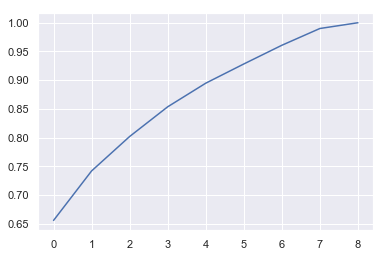

In [39]:
plt.plot(cum_var_exp)

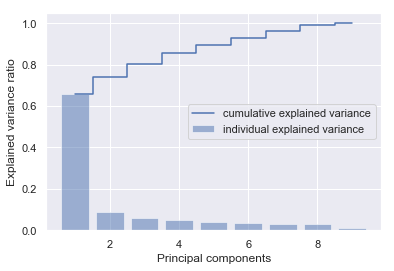

In [40]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

In [41]:
#Based on Eigen values, 7 components carry more than 95% variance.

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [42]:
from sklearn import model_selection

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_std, y, test_size=test_size, random_state=seed)

In [44]:
pca=PCA() 
pca.fit(X_train) 
X_pca=pca.transform(X_train) 
#let's check the shape of X_pca array
print ("shape of X_pca", X_pca.shape)
#measuring the variance ratio of the principal components.
#ex_variance=np.var(X_pca,axis=0)
#ex_variance_ratio = ex_variance/np.sum(ex_variance)
#print (ex_variance_ratio)
print("pca explained variance:", pca.explained_variance_)
print("no of principal components:", pca.n_components_)

shape of X_pca (483, 9)
pca explained variance: [6.02185595 0.81398064 0.52368531 0.50221225 0.38910919 0.32122922
 0.29589439 0.26368979 0.08378797]
no of principal components: 9


In [45]:
#Based on Eigen values, 7 components carry more than 95% variance.
#Hence use only 7 components

In [46]:
pca=PCA(n_components=7) 
pca.fit(X_train) 
X_pca=pca.transform(X_train) 
#let's check the shape of X_pca array
print ("shape of X_pca", X_pca.shape)
#measuring the variance ratio of the principal components.
ex_variance=np.var(X_pca,axis=0)
ex_variance_ratio = ex_variance/np.sum(ex_variance)
print (ex_variance_ratio)
print("pca explained variance:", pca.explained_variance_)
print("no of principal components:", pca.n_components_)

shape of X_pca (483, 7)
[0.6790571  0.09178887 0.05905359 0.05663217 0.04387806 0.03622355
 0.03336665]
pca explained variance: [6.02185595 0.81398064 0.52368531 0.50221225 0.38910919 0.32122922
 0.29589439]
no of principal components: 7


In [47]:
train_pca = pca.transform(X_train)
test_pca = pca.transform(X_test)

# Q10 Find correlation between components and features

In [48]:
features = df.columns
features = features.drop('Class')
features

Index(['ClumpThickness', 'Cell Size', 'Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli',
       'Bland Chromatin', 'Mitoses'],
      dtype='object')

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\figure.py:2366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


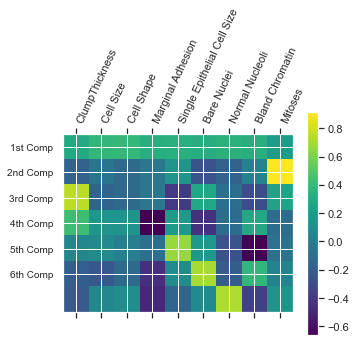

In [49]:
plt.matshow(pca.components_,cmap='viridis')
plt.yticks([0,1,2,3,4,5],['1st Comp','2nd Comp','3rd Comp','4th Comp','5th Comp','6th Comp'],fontsize=10)
plt.colorbar()
plt.xticks(range(len(features)),features,rotation=65,ha='left')
plt.tight_layout()
plt.show()

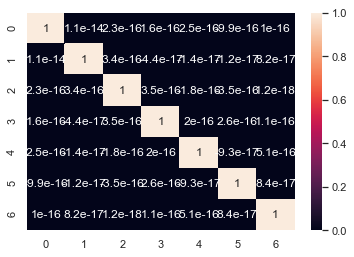

In [60]:
pca_new_df=pd.DataFrame(X_pca)
sns.heatmap(pca_new_df.corr(), annot=True)

As expected, after PCA, there is no covariance between new features 

In [50]:
pca.components_

array([[ 0.30233494,  0.38762342,  0.38967419,  0.33305919,  0.34052622,
         0.32549403,  0.35097452,  0.32647262,  0.2095121 ],
       [-0.15761176, -0.04476264, -0.11624142, -0.03273197,  0.16067594,
        -0.25183329, -0.15905714,  0.03661137,  0.91798424],
       [ 0.75487337, -0.15404561, -0.11521431, -0.03138786, -0.39842496,
         0.28753716, -0.08934096, -0.28262336,  0.25079626],
       [ 0.42885257,  0.16253676,  0.15957631, -0.66012893,  0.19827155,
        -0.42875652, -0.10243284,  0.29000287, -0.10341449],
       [ 0.05524519,  0.09717082,  0.01349854, -0.08648601,  0.67228646,
         0.17868507, -0.25489135, -0.65230963, -0.07395182],
       [-0.19100591, -0.22497006, -0.11256545, -0.4447703 ,  0.10943789,
         0.70965842, -0.19250327,  0.38334661,  0.05300712],
       [-0.19938774,  0.07192422,  0.11347872, -0.4816099 , -0.1427842 ,
         0.08875976,  0.72483234, -0.36371835,  0.15590811]])

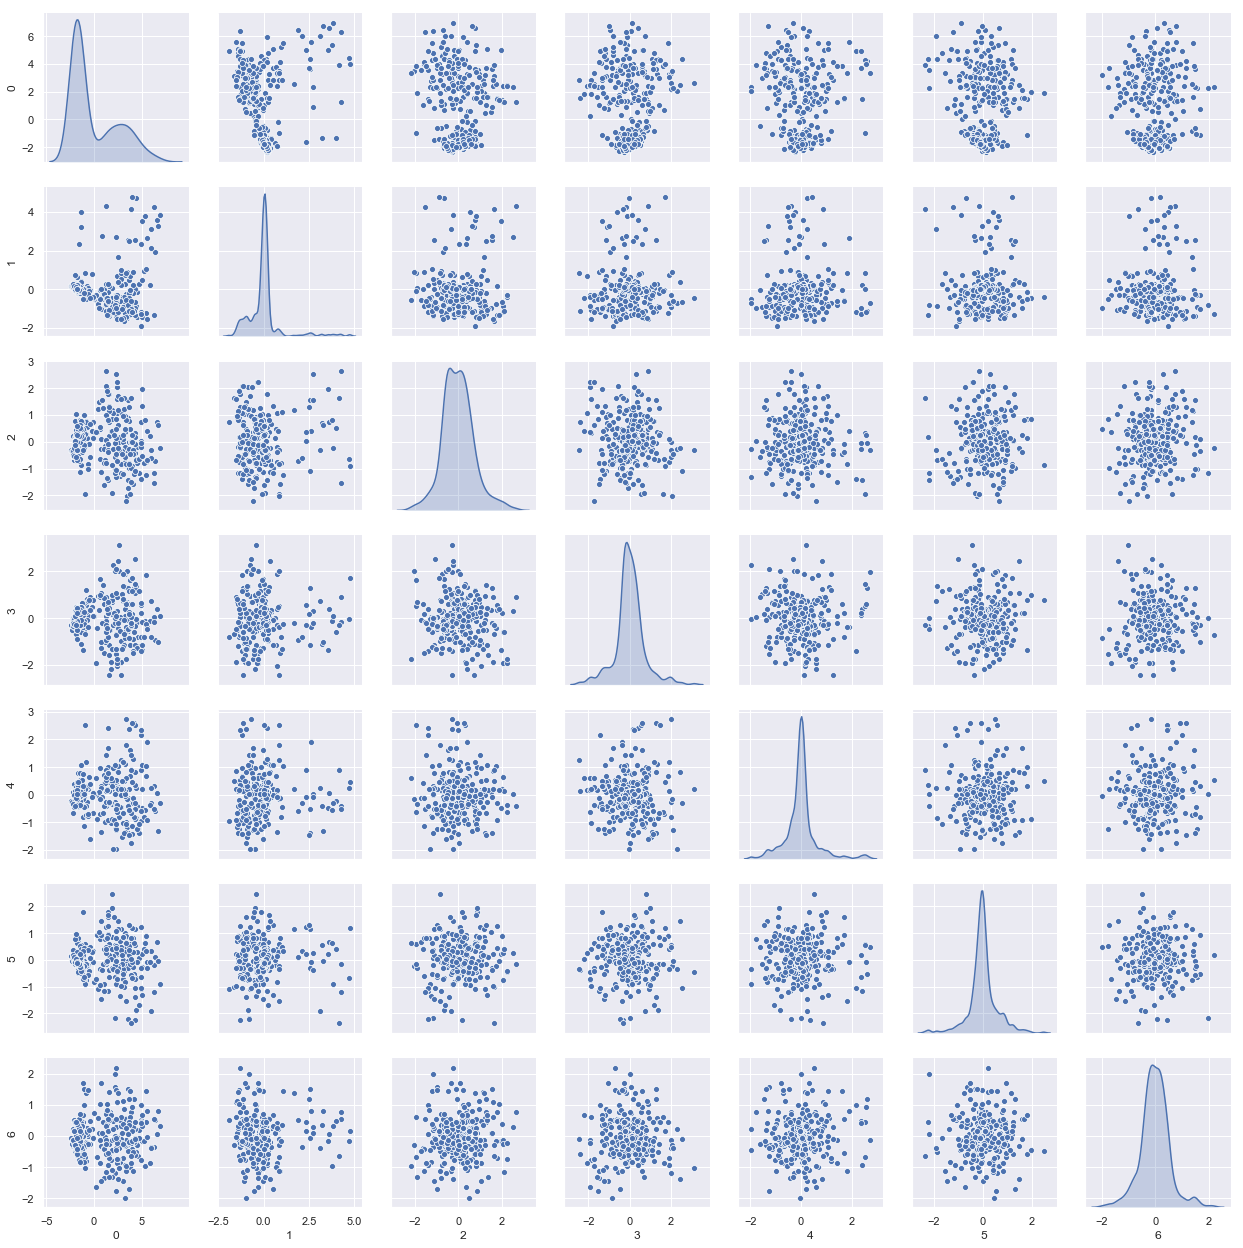

In [64]:
sns.pairplot(pca_new_df, diag_kind='kde', palette="husl")

In [51]:
# Let us build a linear regression model on the PCA dimensions 

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression

regression_model = LinearRegression()
regression_model.fit(train_pca, y_train)

regression_model.coef_

array([ 0.34791869, -0.10540274,  0.13480729, -0.01538995, -0.00401861,
        0.16176972,  0.02039547])

In [52]:
regression_model.intercept_

2.6832298136645965

In [53]:
regression_model.score(test_pca, y_test)

0.8298587129326508

In [54]:
# P_reduce represents reduced mathematical spac....

# Reducing from 10 to 7 dimension space 
#since until 7th Principal component, 95% variance is captured
P_reduce = np.array(eigvectors_sorted[0:7])   

X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot
#Proj_data_df

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

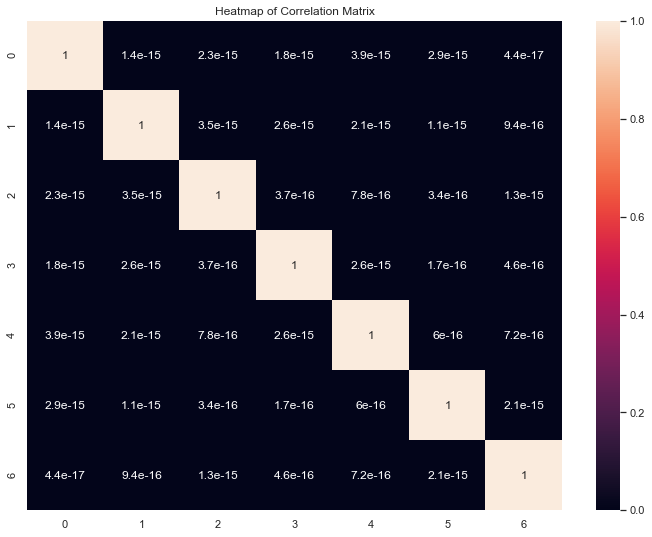

In [55]:
Proj_data_can_df = Proj_data_df.join(y)
#Let's see how these data are correlated
corr_matrix = Proj_data_df.corr().abs()
plt.figure(figsize = (12,9))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(corr_matrix,annot=True)#, xticklabels=corr_matrix.columns.values, yticklabels=corr_matrix.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

As expected, after PCA, there is no covariance between new features 

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


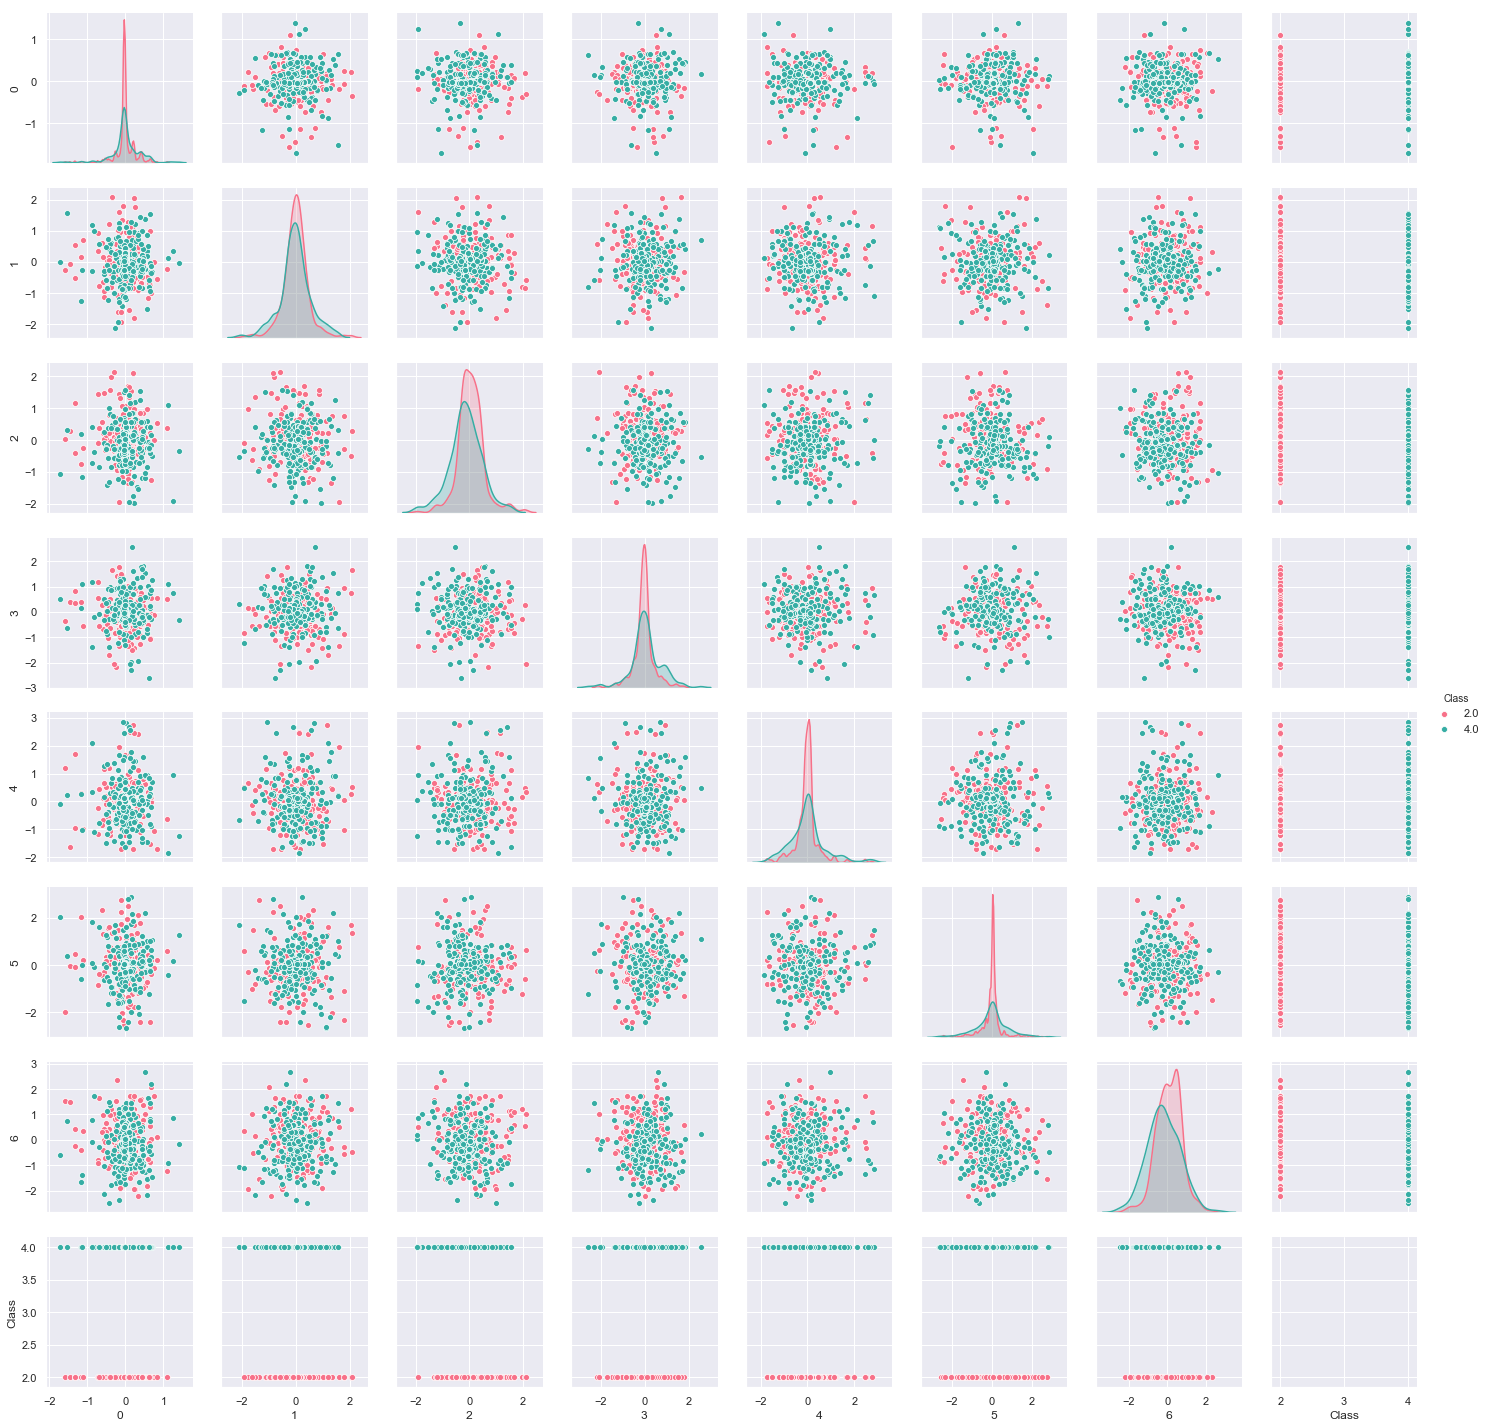

In [56]:
#Let us check it visually
Proj_data_mpg_df = Proj_data_df.join(y)

sns.pairplot(Proj_data_mpg_df, diag_kind='kde', palette="husl", hue = "Class") 

In [57]:
# Let us build a linear regression model on the projection features received using np array functions

# Import Linear Regression machine learning library

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

regression_model.coef_

array([0.17269962, 0.13499634, 0.10040729, 0.03725959, 0.03713272,
       0.30960378, 0.09577344, 0.12077901, 0.0256697 ])

In [58]:
regression_model.intercept_

2.674103425655517

In [59]:
regression_model.score(X_test, y_test)

0.8308752602543354